**EXPLORATORY DATA ANALYSIS**
- SCENARIO
- EXPLORATORY DATA ANALYSIS (EDA)
   - Dataset description
   - Assumptions
      - Linearity
      - Monotonicity
      - Feature interactions
      - Multicollinearity




***EXPLORATORY DATA ANALYSIS (EDA)***


DATASET DESCRIPTION

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import matplotlib

In [ ]:
df = pd.read_csv("/content/cox-violent-parsed_filt.csv")
print(f'The dimension of the dataset is : {df.shape}')

The dimension of the dataset is : (18316, 40)


In [ ]:
df.count()

,0
id,11001
name,18316
first,18316
last,18316
sex,18316
dob,18316
age,18316
age_cat,18316
race,18316
juv_fel_count,18316


In [ ]:
features = [
    'sex',
    'age',
    'race',
    'juv_fel_count',
    'juv_misd_count',
    'juv_other_count',
    'priors_count',
    'c_charge_degree',
]
df[features].count()

,0
sex,18316
age,18316
race,18316
juv_fel_count,18316
juv_misd_count,18316
juv_other_count,18316
priors_count,18316
c_charge_degree,17449


These will be out predictive variables. Charge degree and days from compas have some missing values.

In [ ]:
df[features].describe(exclude="number")

,sex,race,c_charge_degree
count,18316,18316,17449
unique,2,6,14
top,Male,African-American,(F3)
freq,14933,9791,10294


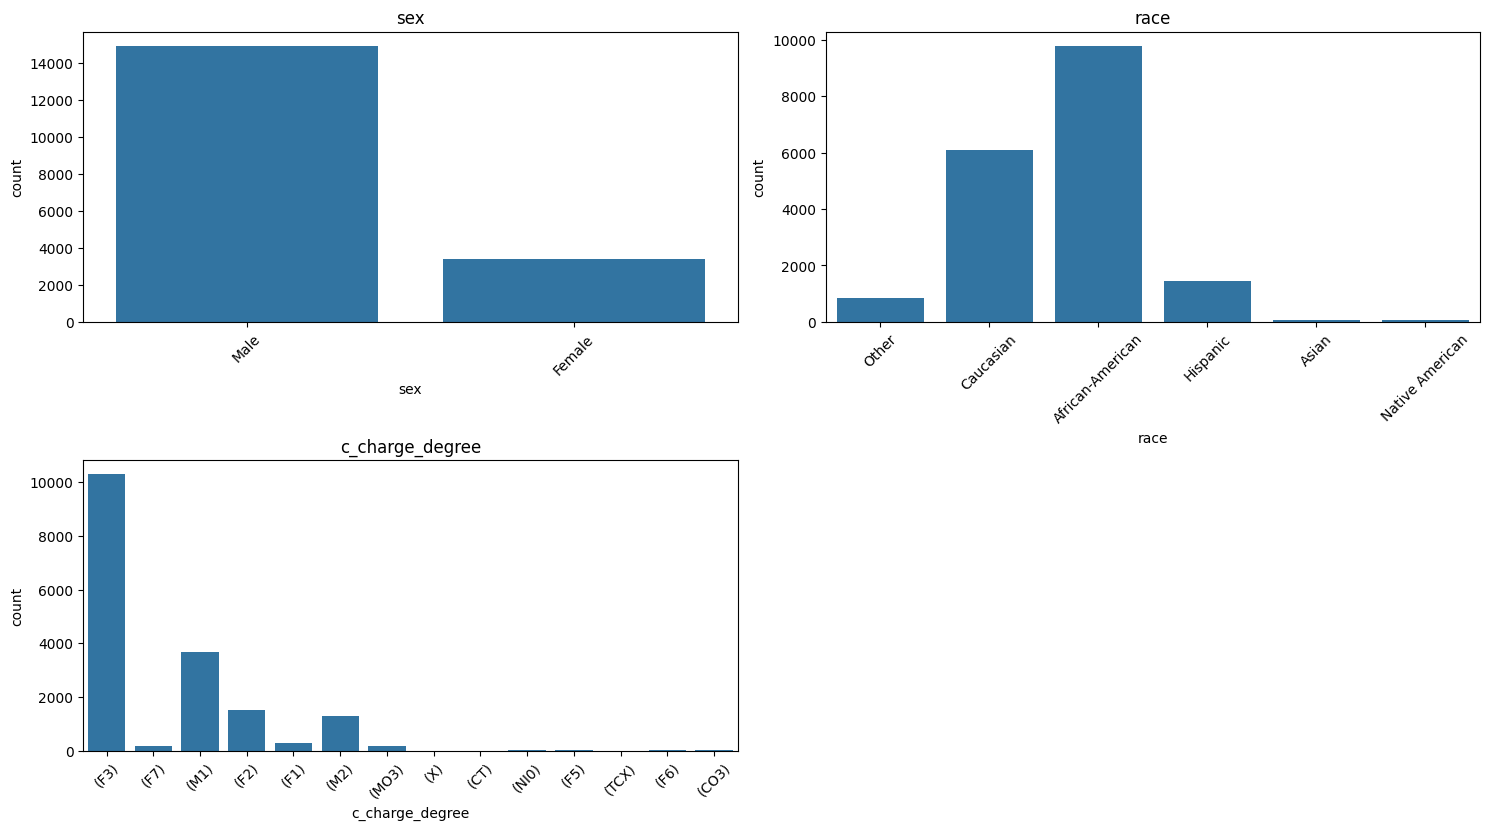

In [ ]:
cat_features = df[features].describe(exclude="number")
plt.figure(figsize=(15, 12))
for i, col in enumerate(cat_features):
    plt.subplot(3, 2, i+1)  # Ajusta filas y columnas según cuántos gráficos
    sns.countplot(x=col, data=df)
    plt.title(col)
    plt.xticks(rotation=45)  # rota etiquetas si son largas
    plt.tight_layout()

plt.show()

- F1 – First‑degree felony (most serious felony in this list).
- F2 – Second‑degree felony.
- F3 – Third‑degree felony.
- F5 – Fifth‑degree felony
- F6 – Sixth‑degree felony
- F7 – Seventh‑degree felony
- M1 – First‑degree misdemeanor (more serious misdemeanor).
- M2 – Second‑degree misdemeanor (less serious misdemeanor).
- TCX – Criminal traffic offense
- CO3 – County ordinance violation (third‑level county ordinance offense).
- MO3 – Municipal ordinance violation (third‑level city/municipal offense).
- ICT – Infraction / citation‑type offense (non‑criminal or low‑level offense).
- NI0 – Other infraction (miscellaneous non‑criminal or minor violation).
- X – Unknown / uncategorized charge degree


Sex: clear imbalance, mostly males

Race: clear imbalance, most are african-american and caucasian

Charge degree: clear imbalance, most are F3 charge

In [ ]:
df[features].select_dtypes(include='number').describe()

,age,juv_fel_count,juv_misd_count,juv_other_count,priors_count
count,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000
mean,34.019273,0.076873,0.098439,0.124263,3.913191
std,11.667811,0.464272,0.517639,0.524537,5.299864
min,18.000000,0.000000,0.000000,0.000000,0.000000
25%,25.000000,0.000000,0.000000,0.000000,0.000000
50%,31.000000,0.000000,0.000000,0.000000,2.000000
75%,41.000000,0.000000,0.000000,0.000000,5.000000
max,96.000000,20.000000,13.000000,17.000000,43.000000


Here we can see that c_days_from_compas has a huge amount of outliers. Also for the juvinile variables 75% have 0 (skewed)

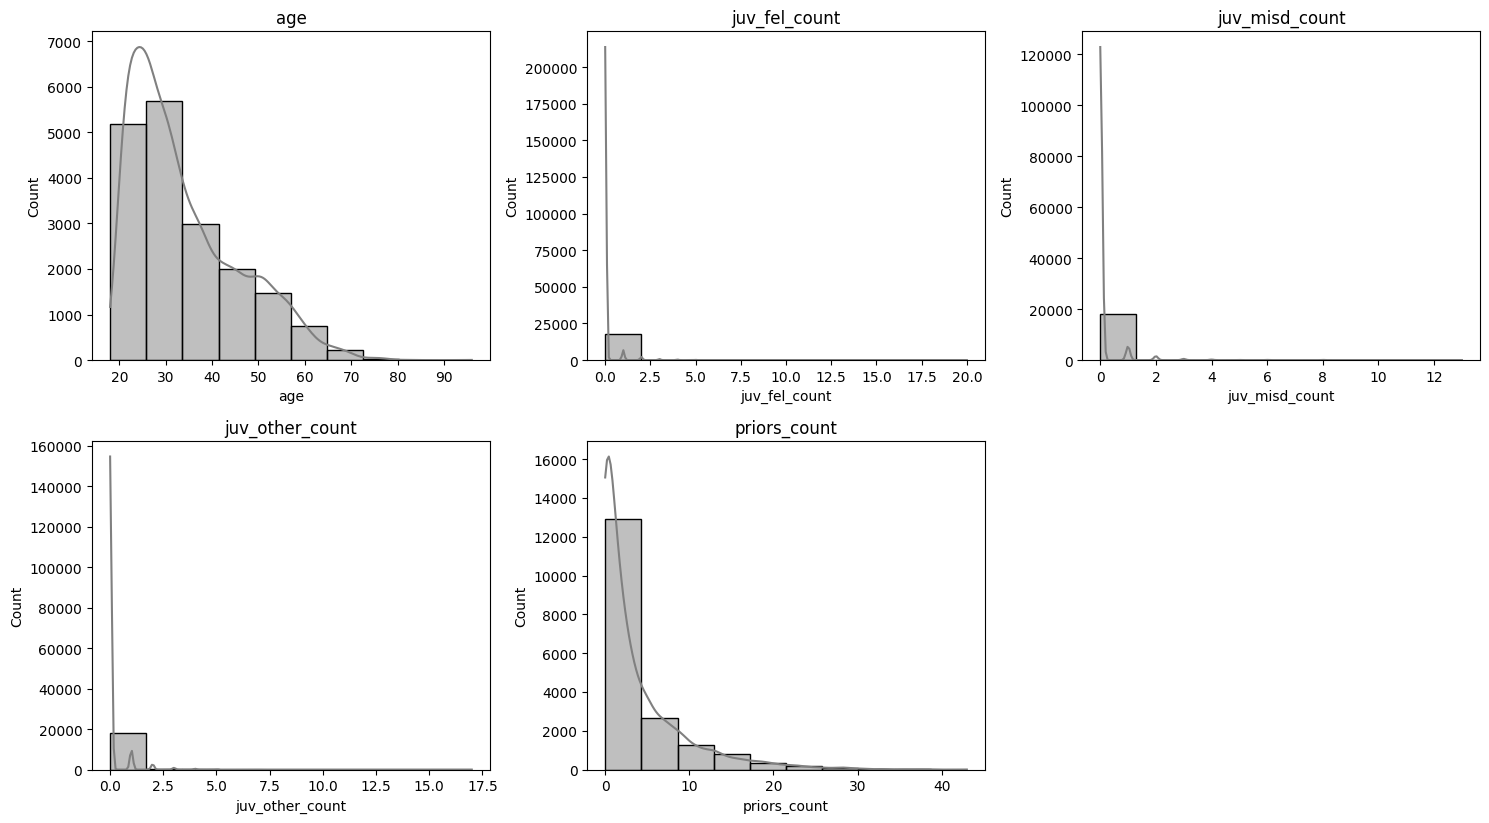

In [ ]:
num_features = df[features].select_dtypes(include='number')
bins = 10
plt.figure(figsize=(15, 12))

for i, col in enumerate(num_features):
    plt.subplot(3, 3, i+1)
    sns.histplot(df[col], kde=True, bins=bins, color='grey', edgecolor='black')
    plt.title(col)

plt.tight_layout()
plt.show()

/tmp/ipython-input-3222812588.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(num_features, labels=num_features.columns, vert=True)


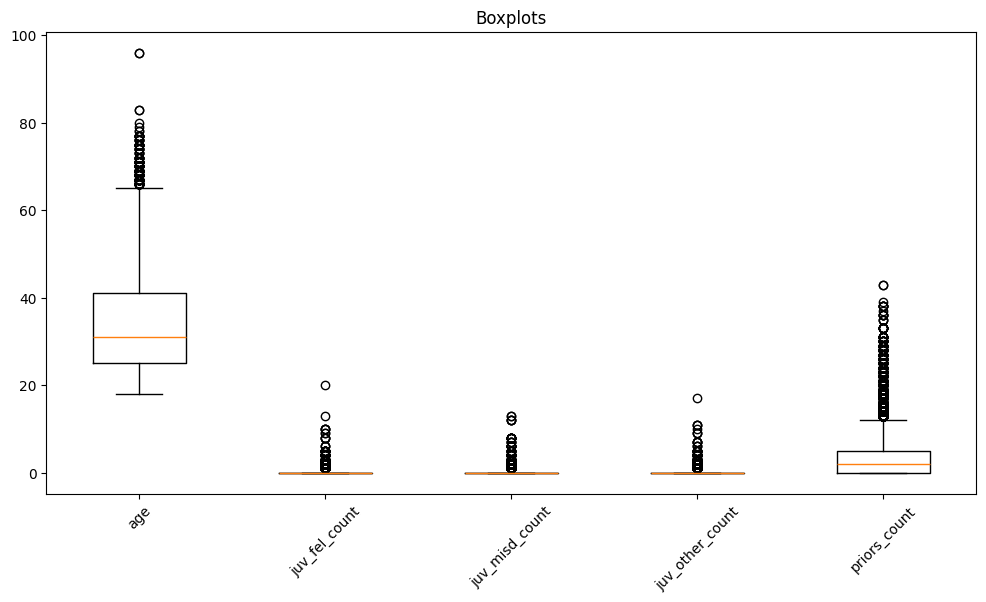

In [ ]:
plt.figure(figsize=(12, 6))
plt.boxplot(num_features, labels=num_features.columns, vert=True)
plt.xticks(rotation=45)
plt.title('Boxplots')
plt.show()

Here we can see that the boxplot of days from compas does not even appear from the huge outlier

In [ ]:
target = df['is_recid']

The target variable will be is_recid because we will predict if the analyzed individual will commit a crime again.

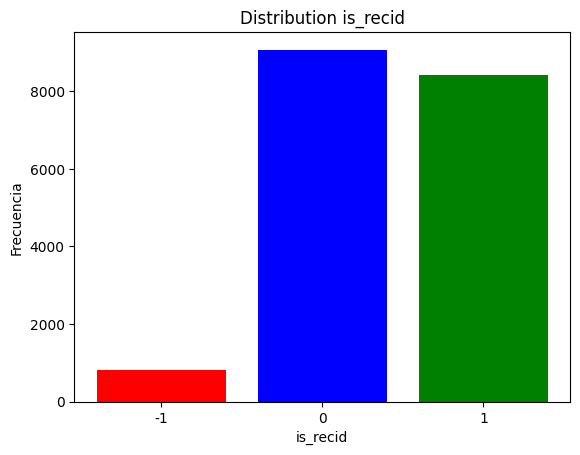

In [ ]:
counts = df['is_recid'].value_counts().sort_index()

plt.bar(counts.index.astype(str), counts.values, color=['red','blue','green'])
plt.xlabel('is_recid')
plt.ylabel('Frecuencia')
plt.title('Distribution is_recid')
plt.show()

The target variable has to be binary but we have 3 values.

In [ ]:
df_filt = df[df["is_recid"] == -1]

In [ ]:
df_filt[features].describe(exclude="number")

,sex,race,c_charge_degree
count,820,820,1
unique,2,6,1
top,Male,African-American,(M1)
freq,656,372,1


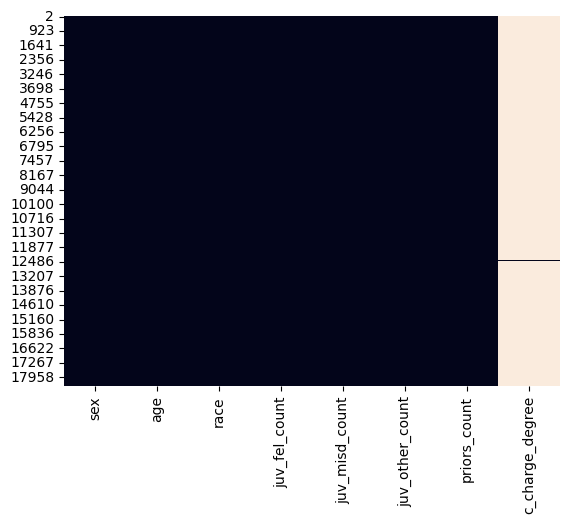

In [ ]:
cmap = sns.mpl_palette("Set2", 2)
sns.heatmap(df_filt[features].isna(),cbar = False)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

legend_handles = [Patch(color=cmap[True], label='NAN'),  # red
                  Patch(color=cmap[False], label='Not NAN')]

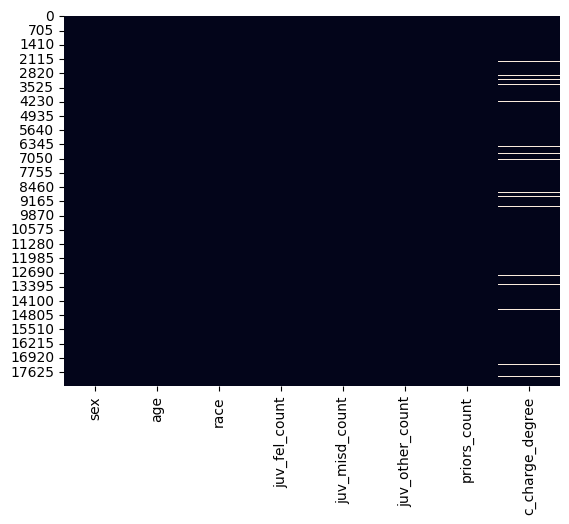

In [ ]:
cmap = sns.mpl_palette("Set2", 2)
sns.heatmap(df[features].isna(),cbar = False)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

legend_handles = [Patch(color=cmap[True], label='NAN'),  # red
                  Patch(color=cmap[False], label='Not NAN')]

In [ ]:
df = df[df["is_recid"] != -1]

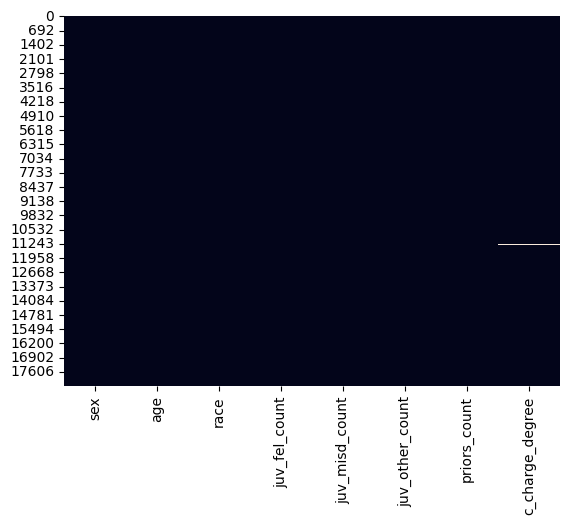

In [ ]:
cmap = sns.mpl_palette("Set2", 2)
sns.heatmap(df[features].isna(),cbar = False)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

legend_handles = [Patch(color=cmap[True], label='NAN'),  # red
                  Patch(color=cmap[False], label='Not NAN')]

In [ ]:
df = df.dropna(subset=["c_charge_degree"])

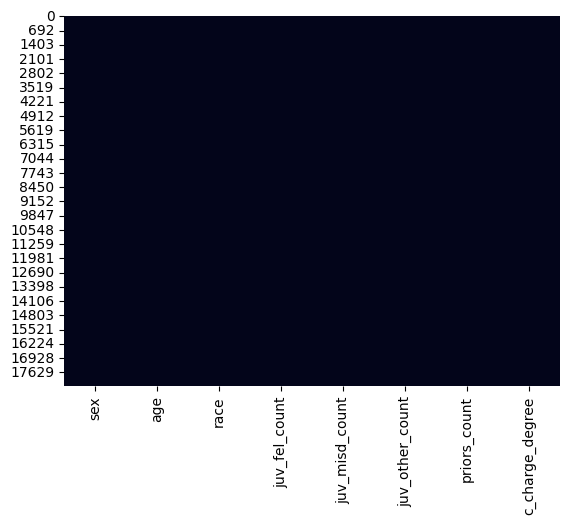

In [ ]:
cmap = sns.mpl_palette("Set2", 2)
sns.heatmap(df[features].isna(),cbar = False)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

legend_handles = [Patch(color=cmap[True], label='NAN'),  # red
                  Patch(color=cmap[False], label='Not NAN')]

ASSUMPTIONS

1.- Task is classification

2.- Linear

In [ ]:
df[features].select_dtypes(include='number').describe()

,age,juv_fel_count,juv_misd_count,juv_other_count,priors_count
count,17448.000000,17448.000000,17448.000000,17448.000000,17448.000000
mean,33.952144,0.080697,0.103336,0.129642,4.107863
std,11.602936,0.475356,0.529882,0.535802,5.355955
min,18.000000,0.000000,0.000000,0.000000,0.000000
25%,25.000000,0.000000,0.000000,0.000000,1.000000
50%,31.000000,0.000000,0.000000,0.000000,2.000000
75%,41.000000,0.000000,0.000000,0.000000,6.000000
max,96.000000,20.000000,13.000000,17.000000,43.000000


/tmp/ipython-input-3573373016.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_data = df.groupby(temp_bins)['is_recid'].mean().reset_index()
/tmp/ipython-input-3573373016.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_data = df.groupby(temp_bins)['is_recid'].mean().reset_index()
/tmp/ipython-input-3573373016.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_data = df.groupby(temp_bins)['

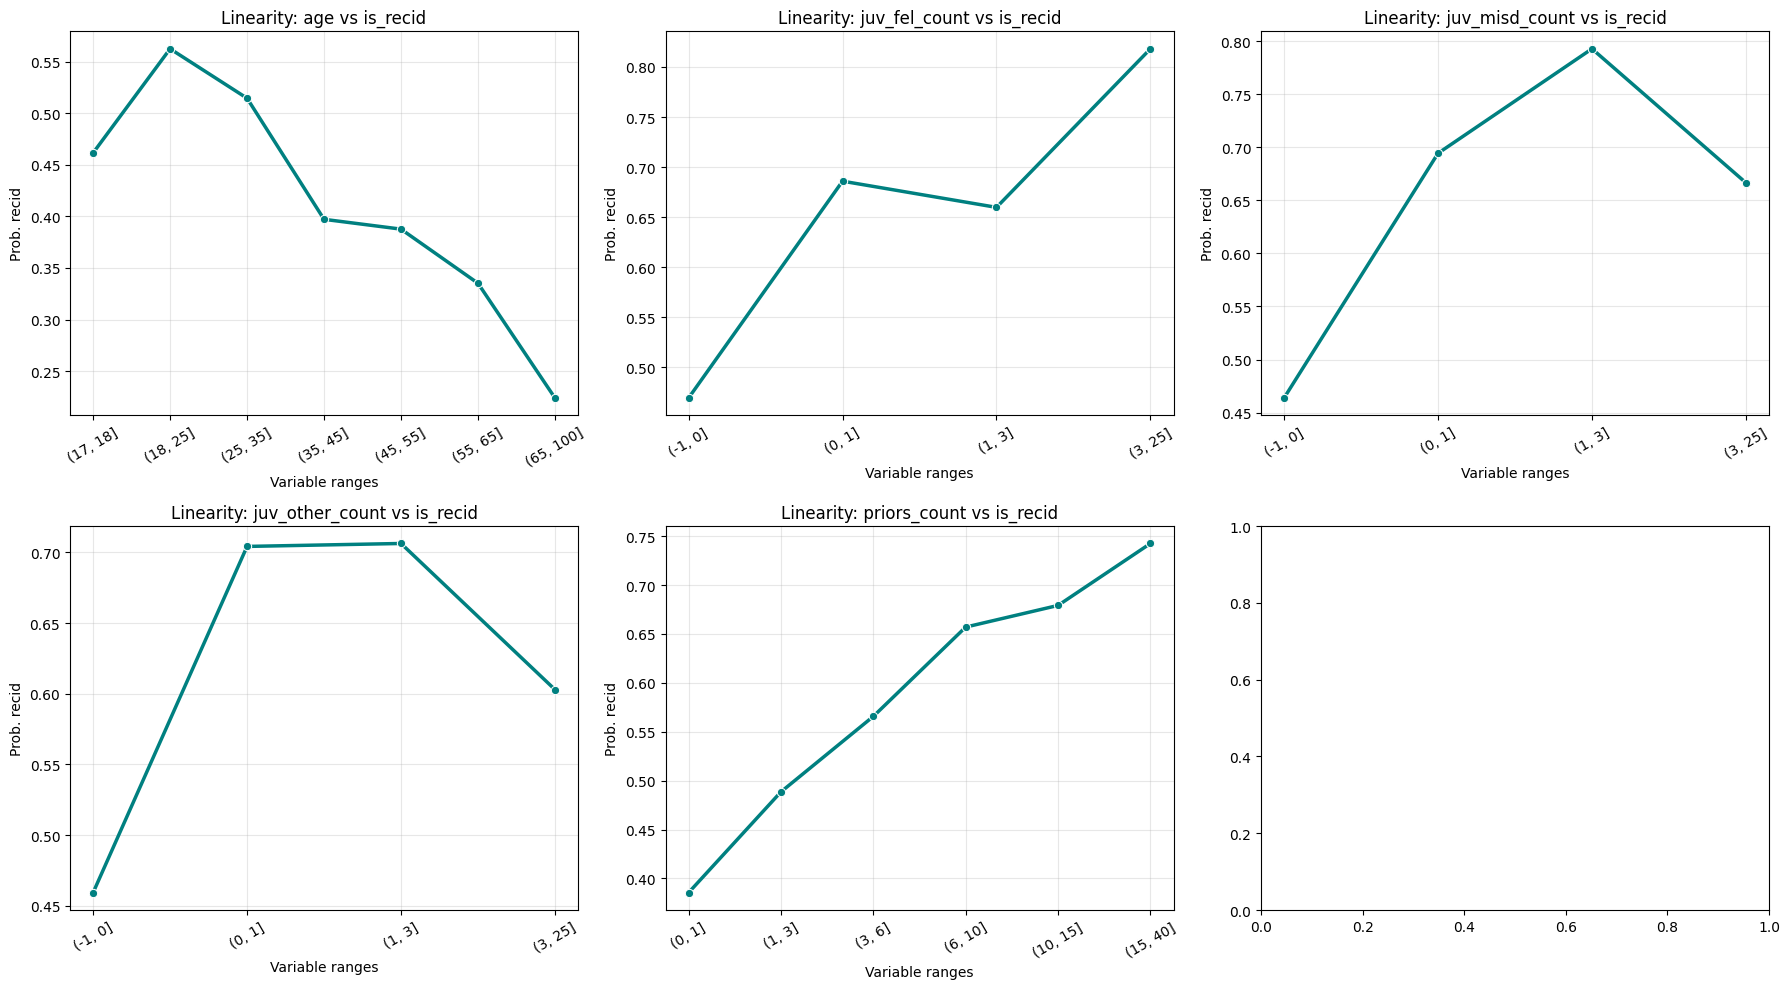

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(num_features):
    if col == 'age':
        bins = [17, 18, 25, 35, 45, 55, 65, 100]
    elif col == 'priors_count':
        bins = [0, 1, 3, 6, 10, 15, 40]
    elif 'juv' in col:
        bins = [-1, 0, 1, 3, 25]
    else: # c_days_from_compas
        bins = [-1, 0, 1, 2, 5, 10, 31]

    temp_bins = pd.cut(df[col], bins=bins)
    binned_data = df.groupby(temp_bins)['is_recid'].mean().reset_index()
    sns.lineplot(ax=axes[i], x=range(len(binned_data)), y=binned_data['is_recid'], marker="o", color='teal', linewidth=2.5)

    axes[i].set_xticks(range(len(binned_data)))
    axes[i].set_xticklabels(binned_data[col].astype(str), rotation=30)
    axes[i].set_title(f'Linearity: {col} vs is_recid')
    axes[i].set_ylabel('Prob. recid')
    axes[i].set_xlabel('Variable ranges')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [ ]:
df['total_juv_count'] = df['juv_fel_count'] + df['juv_misd_count'] + df['juv_other_count']
num_features2 = [
    'age',
    'total_juv_count',
    'priors_count',
    'c_days_from_compas'
]
features2 = [
    'sex',
    'age',
    'race',
    'total_juv_count',
    'priors_count',
    'c_charge_degree',
    'c_days_from_compas'
]

/tmp/ipython-input-3168070903.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_data = df.groupby(temp_bins)['is_recid'].mean().reset_index()
/tmp/ipython-input-3168070903.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_data = df.groupby(temp_bins)['is_recid'].mean().reset_index()
/tmp/ipython-input-3168070903.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned_data = df.groupby(temp_bins)['

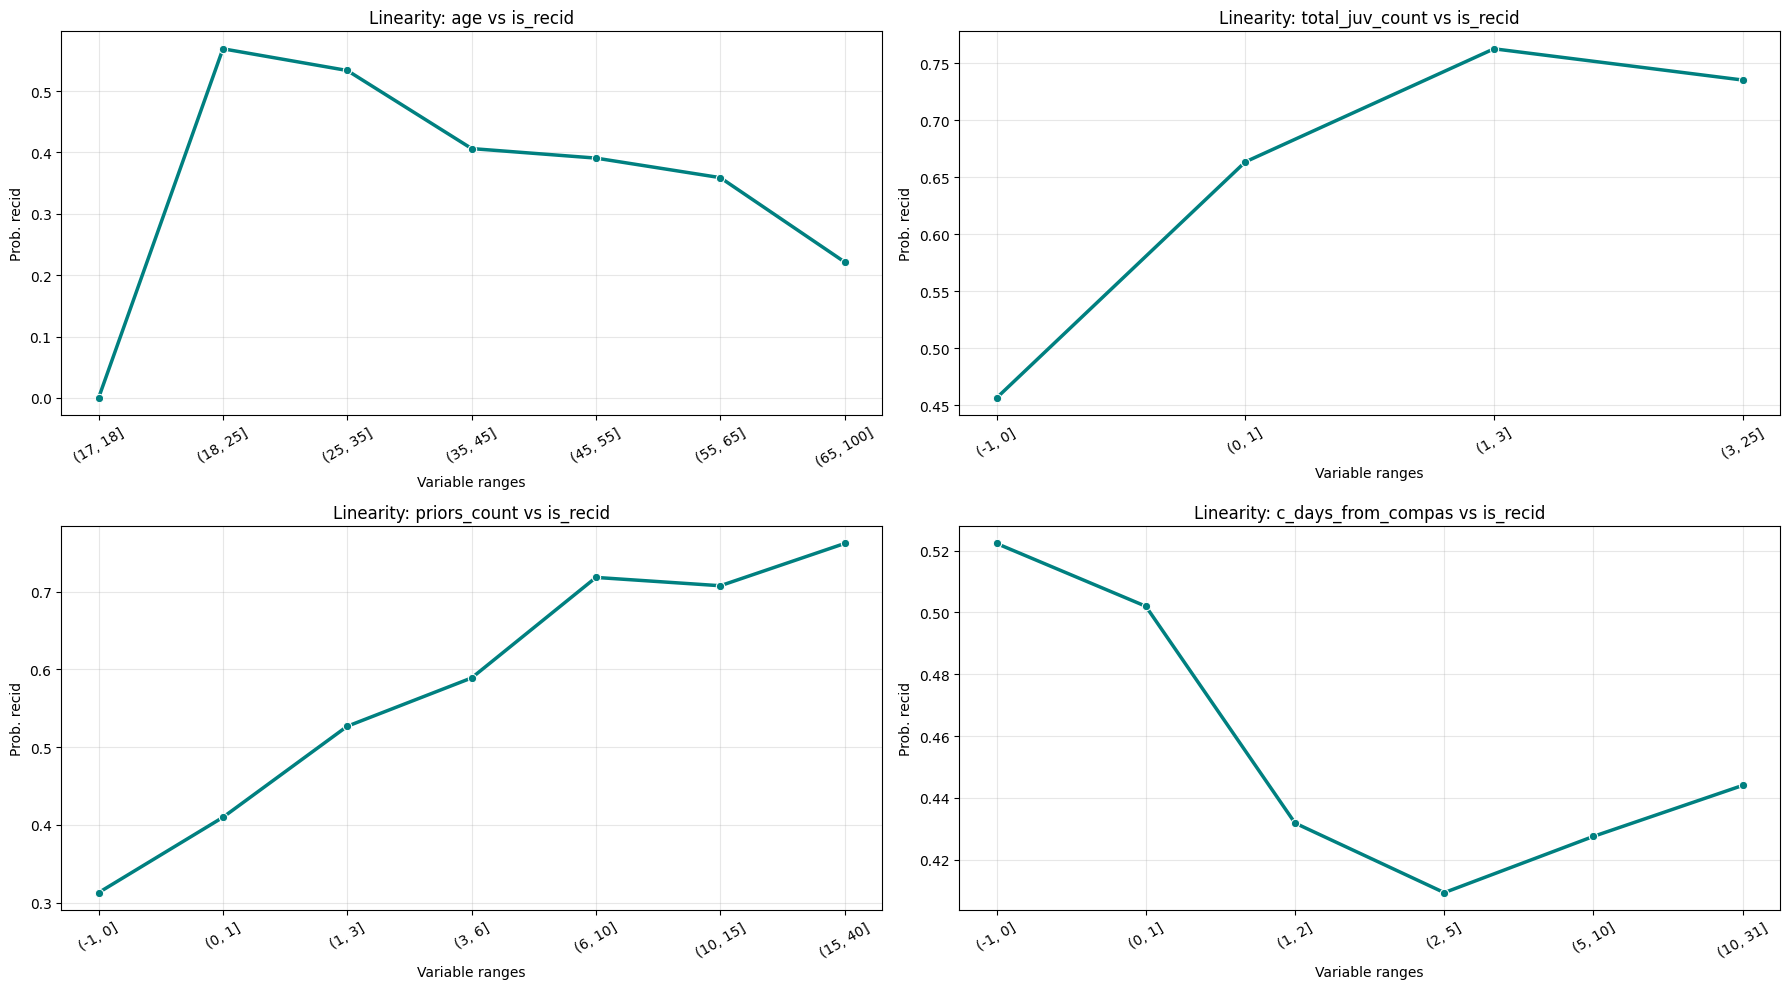

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(num_features2):
    if col == 'age':
        bins = [17, 18, 25, 35, 45, 55, 65, 100]
    elif col == 'priors_count':
        bins = [-1, 0, 1, 3, 6, 10, 15, 40]
    elif 'juv' in col:
        bins = [ -1, 0, 1, 3, 25]
    else: # c_days_from_compas
        bins = [-1, 0, 1, 2, 5, 10, 31]

    temp_bins = pd.cut(df[col], bins=bins)
    binned_data = df.groupby(temp_bins)['is_recid'].mean().reset_index()
    sns.lineplot(ax=axes[i], x=range(len(binned_data)), y=binned_data['is_recid'], marker="o", color='teal', linewidth=2.5)

    axes[i].set_xticks(range(len(binned_data)))
    axes[i].set_xticklabels(binned_data[col].astype(str), rotation=30)
    axes[i].set_title(f'Linearity: {col} vs is_recid')
    axes[i].set_ylabel('Prob. recid')
    axes[i].set_xlabel('Variable ranges')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

MONOTONOCITY

Juv, priors and days from compass is not is not monotonic

FEATURE INTERACTION

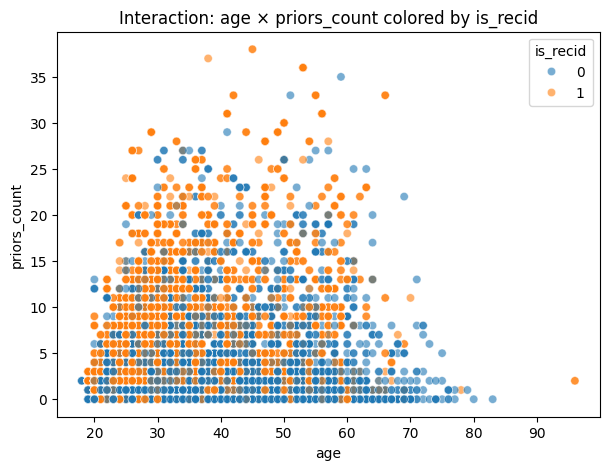

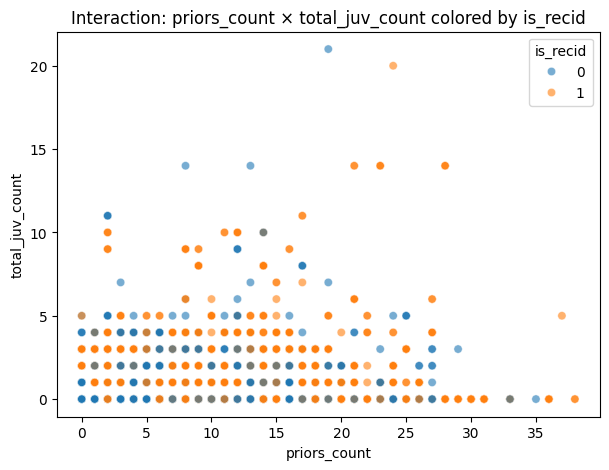

In [ ]:
num_interactions = [
    ('age', 'priors_count'),
    ('priors_count', 'total_juv_count')
]

for x, y in num_interactions:
    plt.figure(figsize=(7,5))
    sns.scatterplot(x=df[x], y=df[y], hue=df['is_recid'], alpha=0.6)
    plt.title(f'Interaction: {x} × {y} colored by is_recid')
    plt.show()

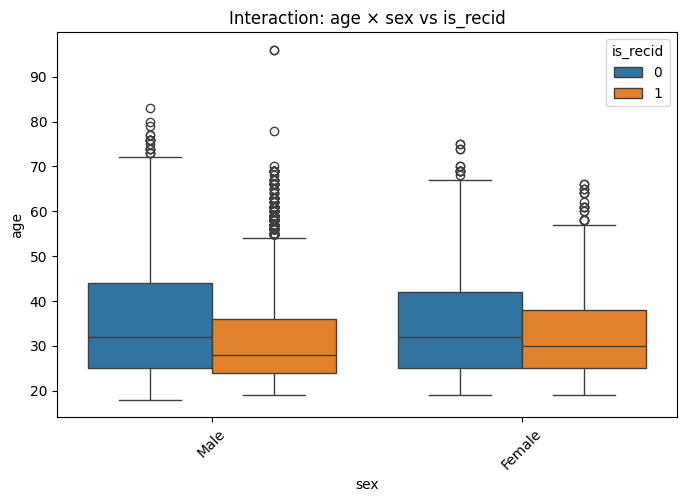

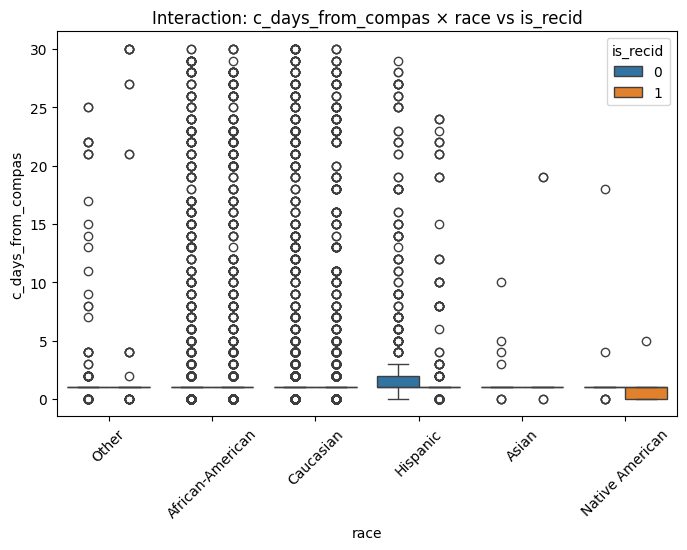

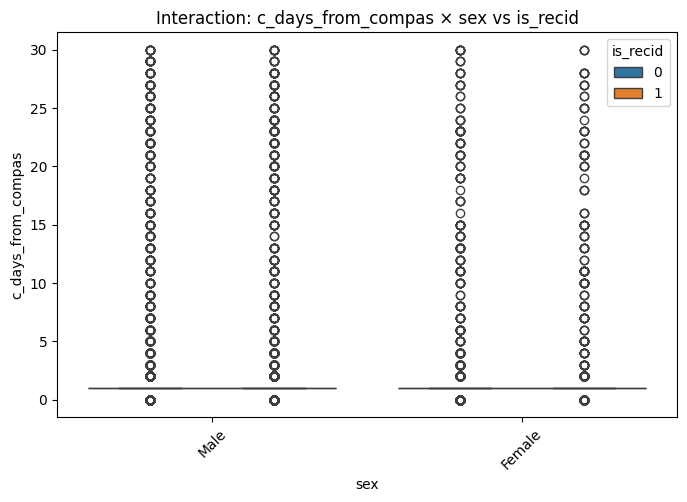

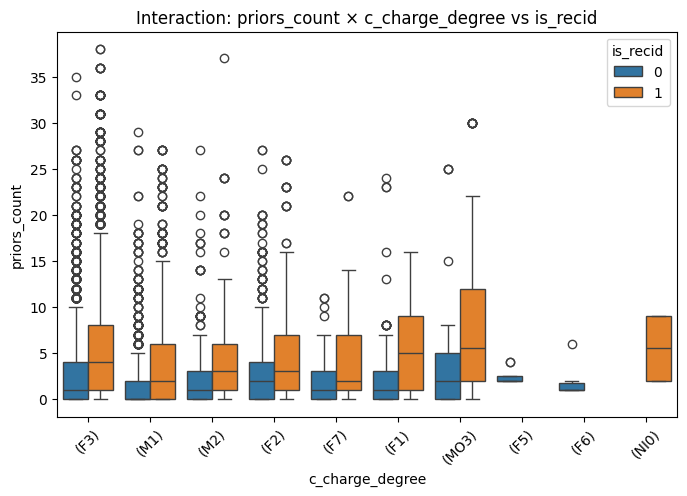

In [ ]:
num_cat_interactions = [
    ('age', 'sex'),
    ('c_days_from_compas', 'race'),
    ('c_days_from_compas', 'sex'),
    ('priors_count', 'c_charge_degree')
]

for num, cat in num_cat_interactions:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=df[cat], y=df[num], hue=df['is_recid'])
    plt.title(f'Interaction: {num} × {cat} vs is_recid')
    plt.xticks(rotation=45)
    plt.show()


Interaction: sex × c_charge_degree (normalized frequencies)
 is_recid                       0         1
sex    c_charge_degree                    
Female (F1)             0.800000  0.200000
       (F2)             0.671429  0.328571
       (F3)             0.572776  0.427224
       (F6)             1.000000  0.000000
       (F7)             0.666667  0.333333
       (M1)             0.704670  0.295330
       (M2)             0.609375  0.390625
       (MO3)            0.428571  0.571429
Male   (F1)             0.624060  0.375940
       (F2)             0.497507  0.502493
       (F3)             0.454084  0.545916
       (F5)             1.000000  0.000000
       (F6)             1.000000  0.000000
       (F7)             0.552632  0.447368
       (M1)             0.545666  0.454334
       (M2)             0.461022  0.538978
       (MO3)            0.289474  0.710526
       (NI0)            0.000000  1.000000


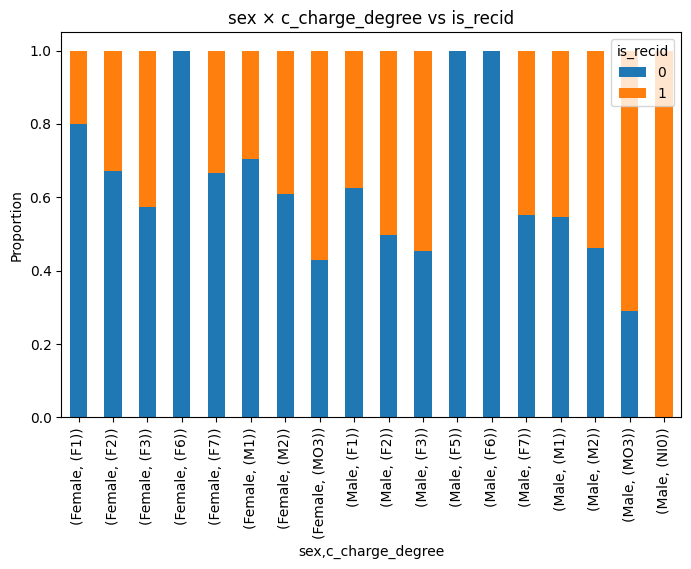


Interaction: race × c_charge_degree (normalized frequencies)
 is_recid                                 0         1
race             c_charge_degree                    
African-American (F1)             0.556522  0.443478
                 (F2)             0.462112  0.537888
                 (F3)             0.424338  0.575662
                 (F5)             1.000000  0.000000
                 (F6)             1.000000  0.000000
                 (F7)             0.554054  0.445946
                 (M1)             0.486579  0.513421
                 (M2)             0.390244  0.609756
                 (MO3)            0.358491  0.641509
                 (NI0)            0.000000  1.000000
Asian            (F2)             0.666667  0.333333
                 (F3)             0.500000  0.500000
                 (M1)             0.947368  0.052632
Caucasian        (F1)             0.970588  0.029412
                 (F2)             0.629496  0.370504
                 (F3)             0.

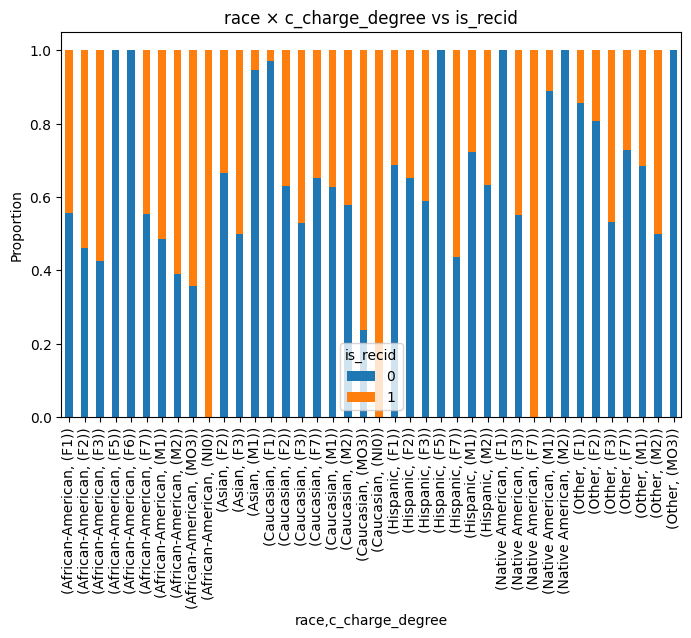

In [ ]:
cat_interactions = [
    ('sex', 'c_charge_degree'),
    ('race', 'c_charge_degree')
]

for cat1, cat2 in cat_interactions:
    cross = pd.crosstab([df[cat1], df[cat2]], df['is_recid'], normalize='index')
    print(f'\nInteraction: {cat1} × {cat2} (normalized frequencies)\n', cross)

    cross.plot(kind='bar', stacked=True, figsize=(8,5))
    plt.title(f'{cat1} × {cat2} vs is_recid')
    plt.ylabel('Proportion')
    plt.show()

MULTICOLLINEARITY: NO

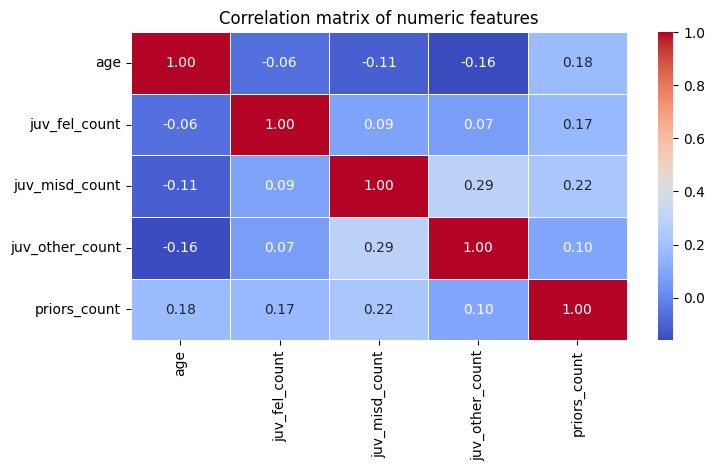

In [ ]:
plt.figure(figsize=(8, 4))
corr_matrix = num_features.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation matrix of numeric features')
plt.show()